# 🇻🇳 Phân loại văn bản tiếng Việt theo chủ đề
**Đề tài:** Phân loại tự động văn bản hành chính / Tin tức tiếng Việt  
**Mô hình:** PhoBERT (Google Colab GPU)  



## BƯỚC 1 — Cài đặt thư viện


In [ ]:
!pip install -q requests beautifulsoup4 lxml
!pip install -q pandas scikit-learn matplotlib seaborn tqdm joblib
!pip install -q underthesea
!pip install -q transformers torch datasets


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


## BƯỚC 2 — Tạo cấu trúc thư mục

In [ ]:
import os

folders = ['data/raw', 'data/processed', 'models', 'results']
for f in folders:
    os.makedirs(f, exist_ok=True)
    print(f'📁 {f}/')

print('\n✅ Cấu trúc thư mục sẵn sàng!')

📁 data/raw/
📁 data/processed/
📁 models/
📁 results/

✅ Cấu trúc thư mục sẵn sàng!


## BƯỚC 3 — Tải dataset + Tiền xử lý
> Dataset: [NamSyntax/vietnamese-news-classification](https://huggingface.co/datasets/NamSyntax/vietnamese-news-classification)  
> ~1.3 triệu bài báo tiếng Việt, gán nhãn sẵn theo **11 chủ đề**.

In [ ]:
# ============================================================
# ĐĂNG NHẬP HUGGING FACE
# ============================================================
from huggingface_hub import login

hf_token = None

# --- Cách 1: Lấy token từ Kaggle Secrets (ưu tiên khi chạy trên Kaggle) ---
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret('HF_TOKEN')
    print('✅ Đã lấy HF_TOKEN từ Kaggle Secrets')
except Exception:
    pass

# --- Cách 2: Nếu chạy trên Colab hoặc không có Kaggle Secrets, nhập tay ---
if not hf_token:
    import getpass
    print('⚠️  Không tìm thấy HF_TOKEN trong Secrets — nhập token thủ công bên dưới:')
    hf_token = getpass.getpass('Dán Hugging Face token (hf_...): ')

login(token=hf_token)
print('✅ Đăng nhập Hugging Face thành công!')

In [ ]:
# ============================================================
# BƯỚC 3A: TẢI DATASET TỪ HUGGING FACE
# ============================================================
from datasets import load_dataset
import pandas as pd
import os

os.makedirs('data/processed', exist_ok=True)

# --- Tải dataset (tự động cache, chỉ tải lần đầu) ---
print('⏳ Đang tải dataset từ Hugging Face...')
ds = load_dataset('NamSyntax/vietnamese-news-classification', split='train')
print(f'✅ Tải xong: {len(ds):,} dòng')

# --- Chuyển sang pandas DataFrame ---
df = ds.to_pandas()

# --- Giữ nguyên 4 cột gốc của dataset: label, title, description, text ---
df = df[['label', 'title', 'description', 'text']].dropna(subset=['text', 'label'])
df = df.reset_index(drop=True)

# --- Lọc trùng lặp theo cột 'text' (nội dung chính dùng để train) ---
so_truoc = len(df)
df.drop_duplicates(subset=['text'], inplace=True)
df = df[df['text'].str.len() > 20].reset_index(drop=True)

print(f'\n📊 Trước lọc trùng : {so_truoc:,} dòng')
print(f'📊 Sau lọc trùng   : {len(df):,} dòng')

df.to_csv('data/processed/data_combined.csv', index=False, encoding='utf-8-sig')
print(f'💾 Lưu: data/processed/data_combined.csv')
print(f'\nPhân phối nhãn (0-10):')
print(df['label'].value_counts().sort_index())

In [ ]:
# ============================================================
# BƯỚC 3B: TẢI STOP WORDS TIẾNG VIỆT TỪ GITHUB
# ============================================================
import requests

STOPWORDS_URL = 'https://raw.githubusercontent.com/stopwords-iso/stopwords-vi/master/stopwords-vi.txt'

def load_stopwords_github(url):
    """Tải stop words từ GitHub, fallback về danh sách mặc định nếu lỗi."""
    try:
        resp = requests.get(url, timeout=10)
        resp.encoding = 'utf-8'
        words = set(line.strip() for line in resp.text.splitlines() if line.strip())
        print(f'✅ Tải stop words từ GitHub: {len(words)} từ')
        return words
    except Exception as e:
        print(f'⚠️  Không tải được từ GitHub ({e}), dùng danh sách mặc định')
        return set([
            'và','của','là','các','để','với','trong','cho','về','từ',
            'có','được','này','đã','không','một','những','theo','ra',
            'đó','thì','trên','mà','khi','đến','bị','vì','tại','hay',
            'hoặc','như','nhưng','cũng','vào','lên','rằng','lại','sau',
            'trước','qua','hơn','đây','ở','cùng','bởi','chỉ','đang',
            'sẽ','nên','phải','vẫn','đều','rất','nữa','thêm','giữa',
            'đi','lúc','nay','xem','tuy','dù','mới','còn','gì','ai',
            'nào','sao','thế','hội','tôi','bạn','anh','chị','ông','bà',
        ])

STOPWORDS = load_stopwords_github(STOPWORDS_URL)

# Lưu stop words ra file để dùng lại
with open('data/stopwords_vi.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(sorted(STOPWORDS)))
print(f'💾 Lưu stop words: data/stopwords_vi.txt')
print(f'   Ví dụ 10 từ đầu: {sorted(list(STOPWORDS))[:10]}')

✅ Tải stop words từ GitHub: 645 từ
💾 Lưu stop words: data/stopwords_vi.txt
   Ví dụ 10 từ đầu: ['a ha', 'a-lô', 'ai', 'ai ai', 'ai nấy', 'alô', 'amen', 'anh', 'bao giờ', 'bao lâu']


In [ ]:
# ============================================================
# BƯỚC 3C: TIỀN XỬ LÝ VĂN BẢN
# ============================================================
import re
import unicodedata
from tqdm import tqdm
tqdm.pandas()

def preprocess(text):
    """
    Pipeline 6 bước:
    1. Chuẩn hóa Unicode NFC
    2. Chuyển chữ thường
    3. Bỏ URL, HTML, email
    4. Bỏ ký tự đặc biệt và số
    5. Tách từ tiếng Việt (underthesea)
    6. Bỏ stop words
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''

    # Bước 1: Chuẩn hóa Unicode
    text = unicodedata.normalize('NFC', text)

    # Bước 2: Chữ thường
    text = text.lower()

    # Bước 3: Bỏ URL, HTML, email
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    # Bước 4: Bỏ ký tự đặc biệt và số
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Bước 5: Tách từ tiếng Việt
    try:
        from underthesea import word_tokenize
        text = word_tokenize(text, format='text')
    except:
        pass

    # Bước 6: Bỏ stop words
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

# --- Đọc file tổng hợp đã gộp ---
df = pd.read_csv('data/processed/data_combined.csv', encoding='utf-8-sig')
print(f'⏳ Tiền xử lý {len(df)} bài...')

df['text_clean'] = df['text'].progress_apply(preprocess)

# Bỏ văn bản quá ngắn sau xử lý
df = df[df['text_clean'].str.len() > 10].reset_index(drop=True)

# Nhãn đã có sẵn dạng số (0-10) từ dataset Hugging Face, không cần map lại
# Nguồn: https://huggingface.co/datasets/NamSyntax/vietnamese-news-classification
LABEL2ID = {
    'thoi_su': 0, 'the_gioi': 1, 'kinh_doanh': 2, 'khoa_hoc_cong_nghe': 3,
    'bat_dong_san': 4, 'suc_khoe': 5, 'the_thao': 6, 'giai_tri': 7,
    'phap_luat': 8, 'giao_duc': 9, 'doi_song': 10,
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LABEL_VI = [
    'Thời sự', 'Thế giới', 'Kinh doanh', 'Khoa học công nghệ',
    'Bất động sản', 'Sức khỏe', 'Thể thao', 'Giải trí',
    'Pháp luật', 'Giáo dục', 'Đời sống',
]
NUM_LABELS = len(LABEL_VI)  # = 11

df['label_id'] = df['label'].astype(int)

# Lưu file đã xử lý hoàn chỉnh
df.to_csv('data/processed/data_clean.csv', index=False, encoding='utf-8-sig')

print(f'\n✅ Tiền xử lý xong: {len(df)} bài')
print(f'💾 Lưu tại: data/processed/data_clean.csv')
print(f'\nPhân phối nhãn:')
print(df['label_id'].map(ID2LABEL).value_counts())
print('\n--- Ví dụ trước / sau ---')
row = df.iloc[0]
print(f'Trước: {str(row["text"])[:120]}')
print(f'Sau  : {str(row["text_clean"])[:120]}')

⏳ Tiền xử lý 1572 bài...


100%|██████████| 1572/1572 [01:06<00:00, 23.81it/s]



✅ Tiền xử lý xong: 1572 bài
💾 Lưu tại: data/processed/data_clean.csv

Phân phối nhãn:
label
y_te         407
the_thao     368
giao_duc     354
kinh_te      347
chinh_tri     96
Name: count, dtype: int64

--- Ví dụ trước / sau ---
Trước: Giá vàng thế giới tăng 3 phiên liên tiếp. Mỗi ounce vàng có thời điểm chạm 4.370 USD một ounce trong phiên đầu tuần, nhờ
Sau  : giá vàng thế_giới tăng phiên liên_tiếp ounce vàng thời_điểm chạm usd ounce phiên đầu tuần nhờ thỏa thuận_hòa bình_mỹ ira


## BƯỚC 4 — Chia tập Train / Val / Test

In [ ]:
# ============================================================
# BƯỚC 4: CHIA DỮ LIỆU  70% train / 15% val / 15% test
# ============================================================
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('data/processed/data_clean.csv', encoding='utf-8-sig')

X    = df['text_clean'].values
y    = df['label'].values
y_id = df['label_id'].values

X_train, X_temp, y_train, y_temp, yid_train, yid_temp = train_test_split(
    X, y, y_id, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test, yid_val, yid_test = train_test_split(
    X_temp, y_temp, yid_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print('📊 Phân chia dữ liệu:')
print(f'  Train : {len(X_train):>5} mẫu  (70%)')
print(f'  Val   : {len(X_val):>5} mẫu  (15%)')
print(f'  Test  : {len(X_test):>5} mẫu  (15%)')
print(f'  Tổng  : {len(X_train)+len(X_val)+len(X_test):>5} mẫu')
print('\n✅ Chia xong!')

📊 Phân chia dữ liệu:
  Train :  1100 mẫu  (70%)
  Val   :   236 mẫu  (15%)
  Test  :   236 mẫu  (15%)
  Tổng  :  1572 mẫu

✅ Chia xong!


## BƯỚC 5 — Huấn luyện PhoBERT
> Kết quả tốt nhất ~94–97%. **Yêu cầu: Runtime → T4 GPU**

In [ ]:
# ============================================================
# BƯỚC 5: HUẤN LUYỆN PHOBERT
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score
import numpy as np, os, json

CHECKPOINT_PATH = 'models/checkpoint.pt'      # Lưu model + optimizer + scheduler + epoch
HISTORY_JSON_PATH = 'results/history.json'    # Lưu lịch sử accuracy dạng JSON dễ đọc
os.makedirs('results', exist_ok=True)

# --- Kiểm tra GPU ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'⚡ Thiết bị: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  Không có GPU! Vào Runtime → Change runtime type → T4 GPU')

# --- Cấu hình ---
MODEL_NAME    = 'vinai/phobert-base'
MAX_LEN       = 256    # Giảm từ 256 -> 160 (đa số tiêu đề+mô tả tiếng Việt không dài, giảm ~35% thời gian/step)
BATCH_SIZE    = 32     # Tăng từ 8 -> 32 nhờ dùng FP16 (giảm bộ nhớ), tận dụng GPU tốt hơn
EPOCHS          = 40   # Tổng số epoch MỤC TIÊU cuối cùng (không đổi giữa các lần chạy)
EPOCHS_PER_RUN  = 7    # Mỗi lần chạy cell chỉ train 7 epoch rồi tự dừng + lưu checkpoint
LR            = 3e-5   # Tăng nhẹ để bù cho batch size lớn hơn
NUM_LABELS    = 11     # 11 chủ đề (dataset NamSyntax)
USE_FP16      = True   # Mixed Precision — tăng tốc ~40-50% trên GPU T4/A100

# --- Dataset (dynamic padding: pad theo batch thay vì pad cứng max_length) ---
class VNTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts, self.labels, self.tok = texts, labels, tokenizer
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return {
            'text': str(self.texts[idx]),
            'label': int(self.labels[idx]),
        }

def make_collate_fn(tokenizer):
    """Pad động theo độ dài lớn nhất TRONG TỪNG BATCH thay vì pad cứng
    tới MAX_LEN cho mọi mẫu — giảm đáng kể số lượng token thừa phải tính toán."""
    def collate_fn(batch):
        texts  = [b['text'] for b in batch]
        labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)
        enc = tokenizer(
            texts, max_length=MAX_LEN, padding=True,   # padding=True -> pad theo batch, không phải 'max_length'
            truncation=True, return_tensors='pt'
        )
        enc['labels'] = labels
        return enc
    return collate_fn

# --- Load model ---
print('\n⏳ Đang tải PhoBERT...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
).to(device)
print('✅ Load model xong!')

collate_fn = make_collate_fn(tokenizer)

# --- DataLoaders: num_workers + pin_memory giúp nạp dữ liệu song song, không chờ CPU ---
train_loader = DataLoader(
    VNTextDataset(X_train, yid_train, tokenizer), batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    VNTextDataset(X_val, yid_val, tokenizer), batch_size=BATCH_SIZE,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    VNTextDataset(X_test, yid_test, tokenizer), batch_size=BATCH_SIZE,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

# --- Optimizer & Scheduler ---
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# --- Mixed Precision (FP16) ---
scaler = torch.amp.GradScaler('cuda', enabled=USE_FP16)

# ============================================================
# RESUME: nếu đã có checkpoint từ lần train trước, nạp lại để train tiếp
# ============================================================
start_epoch  = 0
best_val_acc = 0
history      = []

if os.path.exists(CHECKPOINT_PATH):
    print(f'🔄 Tìm thấy checkpoint tại {CHECKPOINT_PATH} — đang nạp lại để train tiếp...')
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    start_epoch  = ckpt['epoch']          # epoch tiếp theo cần chạy
    best_val_acc = ckpt['best_val_acc']
    history      = ckpt['history']
    print(f'✅ Đã nạp xong! Tiếp tục từ epoch {start_epoch + 1}, best_val_acc hiện tại = {best_val_acc:.4f}')
else:
    print('ℹ️  Không có checkpoint cũ — bắt đầu train từ epoch 1')

# Điểm dừng của LẦN CHẠY NÀY = start_epoch + 7, nhưng không vượt quá EPOCHS (40)
end_epoch = min(start_epoch + EPOCHS_PER_RUN, EPOCHS)

if start_epoch >= EPOCHS:
    print(f'\n🎉 Đã hoàn thành đủ {EPOCHS} epoch từ trước — không cần train thêm!')
else:
    print(f'▶ Lần này sẽ train từ epoch {start_epoch + 1} đến epoch {end_epoch} '
          f'({end_epoch - start_epoch} epoch, còn lại {EPOCHS - end_epoch} epoch sau lần này)')

# --- Hàm đánh giá (cũng chạy FP16 để nhanh hơn) ---
def evaluate(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            with torch.autocast(device_type='cuda', enabled=USE_FP16):
                out = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device)
                )
            preds += torch.argmax(out.logits, dim=1).cpu().tolist()
            trues += batch['labels'].tolist()
    return np.array(preds), np.array(trues)

# --- Vòng lặp train ---
print('\n' + '='*50)
print(' BẮT ĐẦU TRAIN PHOBERT')
print('='*50)

for epoch in range(start_epoch, end_epoch):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:  # Không dùng progress bar theo batch — tránh in tràn dòng gây lag
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        labs = batch['labels'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', enabled=USE_FP16):
            out = model(input_ids=ids, attention_mask=mask, labels=labs)
            loss = out.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        correct    += (torch.argmax(out.logits, dim=1) == labs).sum().item()
        total      += labs.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    # Val dùng để chọn checkpoint tốt nhất lưu lại (không rò rỉ thông tin từ tập test)
    val_preds, val_true = evaluate(val_loader)
    val_acc = accuracy_score(val_true, val_preds)

    # Test chỉ dùng để theo dõi/vẽ biểu đồ Train vs Test, KHÔNG dùng để chọn model
    test_preds_epoch, test_true_epoch = evaluate(test_loader)
    test_acc = accuracy_score(test_true_epoch, test_preds_epoch)

    history.append({'epoch': epoch+1, 'train_loss': round(train_loss,4),
                    'train_acc': round(train_acc,4), 'val_acc': round(val_acc,4),
                    'test_acc': round(test_acc,4)})
    print(f'▶ Epoch {epoch+1:>2}/{EPOCHS}  |  Loss: {train_loss:.4f}  |  Train: {train_acc:.4f}  |  Val: {val_acc:.4f}  |  Test: {test_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('models/phobert_best', exist_ok=True)
        model.save_pretrained('models/phobert_best')
        tokenizer.save_pretrained('models/phobert_best')
        print(f'   💾 Đã lưu checkpoint tốt nhất (val_acc={val_acc:.4f})')

    # --- Lưu checkpoint TIẾN ĐỘ sau MỌI epoch (không chỉ epoch tốt nhất) ---
    # Để nếu bị ngắt giữa chừng (hết giờ Kaggle/Colab, mất mạng...) vẫn resume được đúng chỗ
    torch.save({
        'epoch': epoch + 1,                      # epoch tiếp theo cần chạy khi resume
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history,
    }, CHECKPOINT_PATH)

    # --- Lưu riêng lịch sử ra JSON (nhẹ, dễ mở xem/vẽ lại biểu đồ mà không cần load model) ---
    with open(HISTORY_JSON_PATH, 'w', encoding='utf-8') as f:
        json.dump({'best_val_acc': best_val_acc, 'history': history}, f, ensure_ascii=False, indent=2)

if end_epoch >= EPOCHS:
    print(f'\n🎉 HOÀN TẤT! Đã train đủ {EPOCHS}/{EPOCHS} epoch. Best Val Accuracy: {best_val_acc:.4f}')
else:
    print(f'\n✅ Đã train xong đợt này: epoch {start_epoch+1}–{end_epoch}/{EPOCHS} '
          f'(còn lại {EPOCHS - end_epoch} epoch). Best Val Accuracy hiện tại: {best_val_acc:.4f}')
    print(f'   👉 Chạy lại chính cell này ở lần sau (checkpoint đã lưu) để train tiếp {EPOCHS_PER_RUN} epoch kế.')


⚡ Thiết bị: cuda
   GPU: Tesla T4

⏳ Đang tải PhoBERT...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

...

  💾 Lưu model tốt nhất! (val_acc=0.9746)

▶ Epoch 4/5


  Training: 100%|██████████| 69/69 [00:53<00:00,  1.30it/s]


  Loss: 0.0565 | Train: 0.9918 | Val: 0.9703

▶ Epoch 5/5


  Training: 100%|██████████| 69/69 [00:54<00:00,  1.27it/s]


  Loss: 0.0389 | Train: 0.9945 | Val: 0.9703

✅ Train xong! Best Val Accuracy: 0.9746


In [ ]:
# ============================================================
# TẢI XUỐNG TIẾN TRÌNH TRAIN HIỆN TẠI (checkpoint + model tốt nhất + history)
# ============================================================
import shutil, os

ZIP_NAME = 'training_progress'
TEMP_DIR = 'progress_export'

# --- Gom các file/thư mục cần thiết vào 1 chỗ trước khi nén ---
shutil.rmtree(TEMP_DIR, ignore_errors=True)
os.makedirs(TEMP_DIR, exist_ok=True)

if os.path.exists('models/checkpoint.pt'):
    shutil.copy('models/checkpoint.pt', f'{TEMP_DIR}/checkpoint.pt')
    print('✅ Đã thêm checkpoint.pt (dùng để resume train tiếp)')
else:
    print('⚠️  Chưa có checkpoint.pt — có thể chưa chạy epoch nào')

if os.path.exists('models/phobert_best'):
    shutil.copytree('models/phobert_best', f'{TEMP_DIR}/phobert_best', dirs_exist_ok=True)
    print('✅ Đã thêm phobert_best (model tốt nhất tính đến hiện tại)')
else:
    print('⚠️  Chưa có phobert_best — chưa có epoch nào đạt val_acc tốt nhất')

if os.path.exists('results/history.json'):
    shutil.copy('results/history.json', f'{TEMP_DIR}/history.json')
    print('✅ Đã thêm history.json (lịch sử accuracy/loss từng epoch)')
else:
    print('⚠️  Chưa có history.json')

# --- Nén thành 1 file zip duy nhất ---
shutil.make_archive(ZIP_NAME, 'zip', TEMP_DIR)
zip_path = f'{ZIP_NAME}.zip'
size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f'\n📦 Đã nén xong: {zip_path}  ({size_mb:.1f} MB)')

# --- Tải xuống (tự nhận diện Colab hay Kaggle) ---
try:
    from google.colab import files
    files.download(zip_path)
    print('✅ Đang tải xuống qua trình duyệt (Colab)...')
except ImportError:
    print('ℹ️  Đang chạy trên Kaggle (hoặc môi trường khác Colab).')
    print(f'   File "{zip_path}" đã nằm sẵn trong thư mục làm việc.')
    print('   Sau khi Save & Run All (Commit), vào tab "Output" để tải file này về.')

## BƯỚC 6 — Đánh giá kết quả & Vẽ biểu đồ


 KẾT QUẢ CUỐI — PHOBERT TRÊN TẬP TEST
Accuracy: 0.9619

              precision    recall  f1-score   support

   Chính trị       0.91      0.67      0.77        15
     Kinh tế       0.93      0.96      0.94        52
    Thể thao       1.00      0.98      0.99        55
        Y tế       0.95      1.00      0.98        61
    Giáo dục       0.98      0.98      0.98        53

    accuracy                           0.96       236
   macro avg       0.95      0.92      0.93       236
weighted avg       0.96      0.96      0.96       236



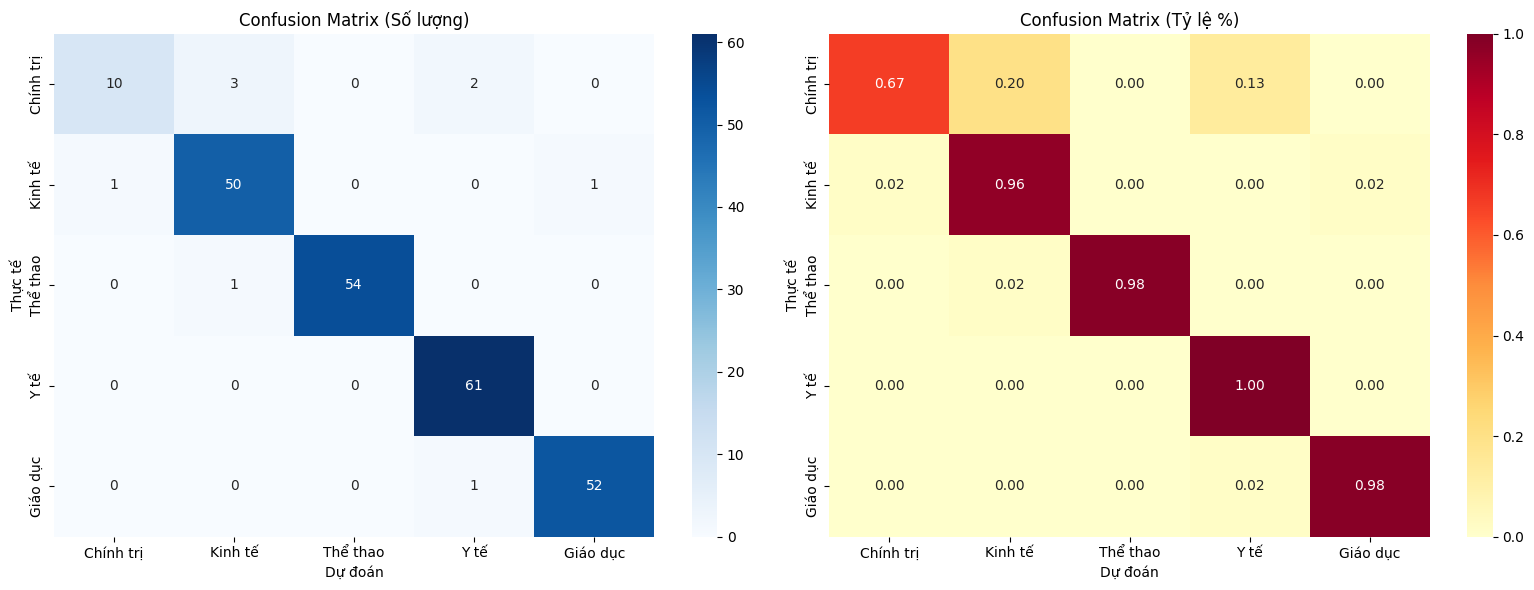

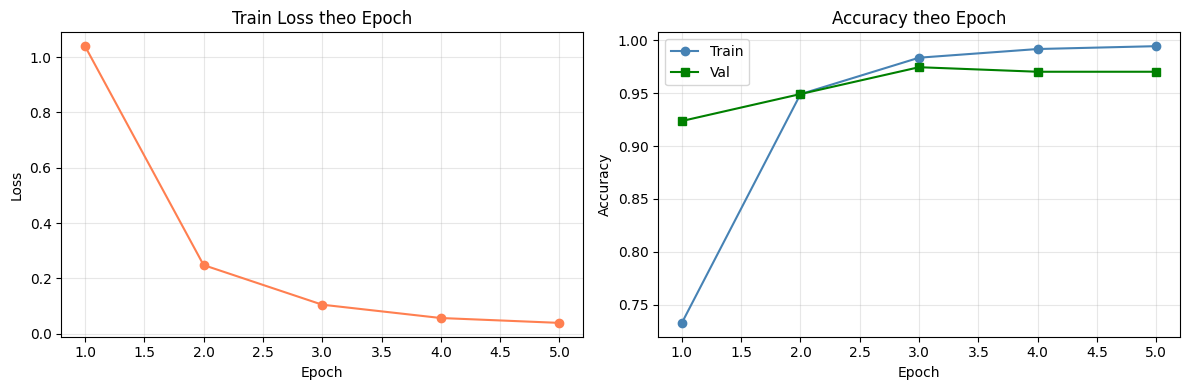

✅ Lưu biểu đồ: results/


In [ ]:
# ============================================================
# BƯỚC 6: ĐÁNH GIÁ TRÊN TẬP TEST + VẼ BIỂU ĐỒ
# ============================================================
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Dự đoán trên tập test ---
test_preds, test_true = evaluate(test_loader)

print('\n' + '='*55)
print(' KẾT QUẢ CUỐI — PHOBERT TRÊN TẬP TEST')
print('='*55)
print(f'Accuracy: {accuracy_score(test_true, test_preds):.4f}\n')
print(classification_report(test_true, test_preds, target_names=LABEL_VI))

# --- Confusion Matrix ---
os.makedirs('results', exist_ok=True)
cm      = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_VI, yticklabels=LABEL_VI, ax=axes[0])
axes[0].set_title('Confusion Matrix (Số lượng)')
axes[0].set_xlabel('Dự đoán'); axes[0].set_ylabel('Thực tế')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=LABEL_VI, yticklabels=LABEL_VI, ax=axes[1])
axes[1].set_title('Confusion Matrix (Tỷ lệ %)')
axes[1].set_xlabel('Dự đoán'); axes[1].set_ylabel('Thực tế')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()

# --- Biểu đồ training history ---
df_hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_hist['epoch'], df_hist['train_loss'], marker='o', color='coral')
axes[0].set_title('Train Loss theo Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(df_hist['epoch'], df_hist['train_acc'], marker='o', label='Train', color='steelblue')
axes[1].plot(df_hist['epoch'], df_hist['test_acc'],  marker='s', label='Test',  color='darkorange')
axes[1].set_title('Accuracy theo Epoch (Train vs Test)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_history.png', dpi=150)
plt.show()
print('✅ Lưu biểu đồ: results/')

## BƯỚC 7 — Dự đoán văn bản mới

In [ ]:
# ============================================================
# BƯỚC 7: DỰ ĐOÁN VĂN BẢN MỚI
# ============================================================
LABEL_MAP_VI = {
    'thoi_su':             '\U0001F4F0 Thời sự',
    'the_gioi':            '\U0001F30D Thế giới',
    'kinh_doanh':          '\U0001F4C8 Kinh doanh',
    'khoa_hoc_cong_nghe':  '\U0001F52C Khoa học công nghệ',
    'bat_dong_san':        '\U0001F3E2 Bất động sản',
    'suc_khoe':            '\U0001F3E5 Sức khỏe',
    'the_thao':            '\u26BD Thể thao',
    'giai_tri':            '\U0001F3AC Giải trí',
    'phap_luat':           '\u2696\uFE0F Pháp luật',
    'giao_duc':            '\U0001F4DA Giáo dục',
    'doi_song':            '\U0001F3E1 Đời sống',
}

def predict(text):
    """Dự đoán nhãn và trả về confidence cho từng chủ đề."""
    model.eval()
    enc = tokenizer(
        text, max_length=256, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        out = model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        )
    probs      = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
    pred_id    = probs.argmax()
    pred_label = ID2LABEL[pred_id]
    return pred_label, probs[pred_id], probs

# --- Thử với nhiều câu mẫu hơn, mỗi chủ đề 3 câu (đủ 11 chủ đề x 3 = 33 câu) ---
test_texts = [
    # 📰 Thời sự
    'Quốc hội thảo luận về dự thảo luật đất đai sửa đổi',
    'Thủ tướng chủ trì hội nghị tổng kết công tác phòng chống thiên tai',
    'Chủ tịch nước tiếp đón đoàn ngoại giao cấp cao thăm chính thức',

    # 🌍 Thế giới
    'Liên Hợp Quốc kêu gọi các bên đối thoại để giải quyết xung đột',
    'Mỹ và Trung Quốc nối lại đàm phán thương mại sau nhiều tháng căng thẳng',
    'Động đất mạnh xảy ra tại Nhật Bản, nhiều khu vực bị ảnh hưởng',

    # 📈 Kinh doanh
    'Ngân hàng Nhà nước giảm lãi suất điều hành hỗ trợ doanh nghiệp',
    'Chỉ số VN-Index tăng điểm mạnh trong phiên giao dịch cuối tuần',
    'Doanh nghiệp xuất khẩu gạo ghi nhận doanh thu kỷ lục trong năm',

    # 🔬 Khoa học công nghệ
    'Apple ra mắt chip xử lý thế hệ mới cho dòng iPhone',
    'Các nhà khoa học phát triển pin mặt trời hiệu suất cao hơn 30%',
    'Trí tuệ nhân tạo được ứng dụng trong chẩn đoán hình ảnh y tế',

    # 🏢 Bất động sản
    'Giá căn hộ chung cư tại Hà Nội tiếp tục tăng trong quý này',
    'Nhiều dự án bất động sản nghỉ dưỡng ven biển được khởi công',
    'Thị trường đất nền vùng ven TP.HCM ghi nhận giao dịch sôi động',

    # 🏥 Sức khỏe
    'Bộ Y tế khuyến cáo người dân tiêm vaccine phòng bệnh đầy đủ',
    'Bệnh viện triển khai kỹ thuật mổ nội soi tiên tiến điều trị ung thư',
    'Số ca mắc sốt xuất huyết tăng cao tại các tỉnh phía Nam',

    # ⚽ Thể thao
    'Đội tuyển U23 Việt Nam giành chiến thắng trong trận ra quân',
    'Cầu thủ Việt Nam chuyển nhượng sang câu lạc bộ nước ngoài thi đấu',
    'Giải marathon quốc tế thu hút hàng nghìn vận động viên tham gia',

    # 🎬 Giải trí
    'Bộ phim mới của đạo diễn Việt Nam công chiếu cuối tuần này',
    'Nam ca sĩ ra mắt album mới sau ba năm vắng bóng',
    'Chương trình truyền hình thực tế gây sốt mạng xã hội tuần qua',

    # ⚖️ Pháp luật
    'Tòa án tuyên án bị cáo trong vụ lừa đảo chiếm đoạt tài sản',
    'Cơ quan điều tra khởi tố thêm nhiều đối tượng liên quan vụ án',
    'Luật mới quy định chặt chẽ hơn về xử phạt vi phạm giao thông',

    # 📚 Giáo dục
    'Bộ Giáo dục công bố kết quả thi tốt nghiệp THPT năm nay',
    'Trường đại học mở thêm ngành đào tạo trí tuệ nhân tạo',
    'Học sinh giỏi quốc gia được tuyển thẳng vào các trường top đầu',

    # 🏡 Đời sống
    'Người dân miền Trung ứng phó với đợt mưa lũ lớn',
    'Giá thực phẩm tại các chợ truyền thống tăng nhẹ dịp cuối năm',
    'Nhiều gia đình lựa chọn du lịch trong nước dịp nghỉ lễ dài ngày',
]

print('=' * 60)
print(' KẾT QUẢ DỰ ĐOÁN')
print('=' * 60)
for text in test_texts:
    label, conf, probs = predict(text)
    label_vi = LABEL_MAP_VI.get(label, label)
    short = text[:55] + '...' if len(text) > 55 else text
    print(f'\n📝 {short}')
    print(f'   → {label_vi}  (confidence: {conf:.1%})')
    top3_idx = probs.argsort()[::-1][:3]
    for i in top3_idx:
        lv = LABEL_MAP_VI.get(ID2LABEL[i], ID2LABEL[i])
        bar = '█' * int(probs[i] * 20)
        print(f'     {lv:22s} {bar:20s} {probs[i]:.1%}')


 KẾT QUẢ DỰ ĐOÁN

📝 Bộ Giáo dục công bố kết quả thi tốt nghiệp THPT năm nay
   → 📚 Giáo dục  (confidence: 98.3%)
     🏛 Chính trị                          0.4%
     📈 Kinh tế                            0.4%
     ⚽ Thể thao                           0.4%
     🏥 Y tế                               0.4%
     📚 Giáo dục      ███████████████████  98.3%

📝 Đội tuyển U23 Việt Nam giành chiến thắng trong trận ra ...
   → 📚 Giáo dục  (confidence: 81.3%)
     🏛 Chính trị                          2.3%
     📈 Kinh tế                            1.2%
     ⚽ Thể thao      ██                   13.9%
     🏥 Y tế                               1.3%
     📚 Giáo dục      ████████████████     81.3%

📝 Ngân hàng Nhà nước giảm lãi suất điều hành hỗ trợ doanh...
   → 📈 Kinh tế  (confidence: 91.3%)
     🏛 Chính trị                          1.3%
     📈 Kinh tế       ██████████████████   91.3%
     ⚽ Thể thao                           0.5%
     🏥 Y tế                               0.7%
     📚 Giáo dục      █      